In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.lista4.data import cargar_datos
from src.lista4.models import ajustar_regresion_lineal
from src.lista4.metrics import riesgo_empirico_cuadratico

Carga de datos y ajuste de modelos

In [2]:
df = cargar_datos('../data/experimento_1.csv')
X1, X2, X_ambas, y = df[['x1']], df[['x2']], df[['x1', 'x2']], df['y']

In [3]:
mod_x1 = ajustar_regresion_lineal(X1, y)
mod_x2 = ajustar_regresion_lineal(X2, y)
mod_ambas = ajustar_regresion_lineal(X_ambas, y)

pred_x1 = mod_x1.predict(X1)
pred_x2 = mod_x2.predict(X2)
pred_ambas = mod_ambas.predict(X_ambas)

riesgo_x1 = riesgo_empirico_cuadratico(y, pred_x1)
riesgo_x2 = riesgo_empirico_cuadratico(y, pred_x2)
riesgo_ambas = riesgo_empirico_cuadratico(y, pred_ambas)

In [4]:
# Tablita
tabla_ej1 = pd.DataFrame({
    'Modelo': ['x1 -> y', 'x2 -> y', '(x1,x2) -> y'],
    'Intercepto': [mod_x1.intercept_, mod_x2.intercept_, mod_ambas.intercept_],
    'Coeficientes': [[mod_x1.coef_[0]], [mod_x2.coef_[0]], list(mod_ambas.coef_)],
    'Riesgo Empírico': [riesgo_x1, riesgo_x2, riesgo_ambas]
})
display(tabla_ej1)

,Modelo,Intercepto,Coeficientes,Riesgo Empírico
0,x1 -> y,-0.082506,[2.920460133812908],1.020069
1,x2 -> y,-0.202971,[-0.04404901062926945],8.374587
2,"(x1,x2) -> y",-0.083790,"[2.925129651807734, -0.1311936588267661]",1.002351


Correlaciones

In [5]:
print(f"Corr(x1, y): {df['x1'].corr(df['y']):.4f}")
print(f"Corr(x2, y): {df['x2'].corr(df['y']):.4f}")
print(f"Corr(x1, x2): {df['x1'].corr(df['x2']):.4f}")

Corr(x1, y): 0.9371
Corr(x2, y): -0.0154
Corr(x1, x2): 0.0326


Graficas

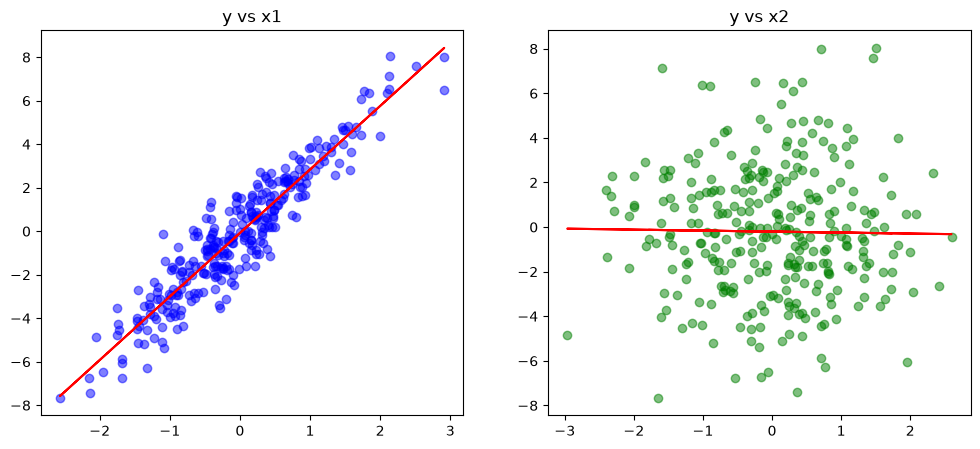

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['x1'], df['y'], color='blue', alpha=0.5)
axes[0].plot(df['x1'], pred_x1, color='red')
axes[0].set_title('y vs x1')

axes[1].scatter(df['x2'], df['y'], color='green', alpha=0.5)
axes[1].plot(df['x2'], pred_x2, color='red')
axes[1].set_title('y vs x2')
plt.show()

Evaluando el menor riesgo empírico obtenido en la tabla entre los modelos individuales, conservaría la variable cuyo riesgo (pérdida cuadrática) sea el número más bajo, ya que es la que mejor se ajusta a los datos por sí sola.